In [4]:
import pandas as pd
df = pd.read_excel("final_dataset_clean.xlsx")
df.head(2)

,Subject,Subject_Type,Relationship,Object,Object_Type,Source_Database,Source_ID,Evidence_Text,Evidence_Type,Confidence_Score
0,Malassezia,Microorganism,causes,Dandruff,Disease,PubMed,37325288/14450/29946996,Clinical studies,Literature,0.95
1,Malassezia,Microorganism,causes,Seborrheic Dermatitis,Disease,PubMed,14450,Clinical studies,Literature,0.90


In [5]:
df.isnull().sum()

Subject             0
Subject_Type        0
Relationship        0
Object              0
Object_Type         0
Source_Database     0
Source_ID           0
Evidence_Text       0
Evidence_Type       0
Confidence_Score    0
dtype: int64

In [6]:
df['Subject_Type'].unique()

array(['Microorganism', 'Enzyme', 'Substance', 'Chemical', 'Drug'],
      dtype=object)

In [7]:
df['Relationship'].unique()

array(['causes', 'associated_with', 'protects', 'decreases_in', 'damages',
       'produces', 'breaks_down', 'activates', 'treats', 'inhibits',
       'disrupts'], dtype=object)

In [8]:
df['Object_Type'].unique()

array(['Disease', 'Biological Process', 'Enzyme', 'Substance', 'Chemical',
       'Symptom', 'Process', 'Biological Structure'], dtype=object)

In [9]:
df['Object'].unique()

array(['Dandruff', 'Seborrheic Dermatitis', 'Opportunistic Infection',
       'Fungal Infection', 'Skin Microbiota', 'Skin Microbiome',
       'Skin Barrier', 'Lipase', 'Sebum', 'Oleic Acid',
       'Scalp Irritation', 'Flaking', 'Inflammatory Response',
       'Ergosterol Synthesis', 'Cytochrome P450', 'Membrane Transport',
       'DNA Replication'], dtype=object)

**cleaning**

In [10]:
# remove extra spaces and standardize text
df['Subject'] = df['Subject'].str.strip().str.title()
df['Object'] = df['Object'].str.strip().str.title()
df['Relationship'] = df['Relationship'].str.strip().str.lower()

In [11]:
df.head()

,Subject,Subject_Type,Relationship,Object,Object_Type,Source_Database,Source_ID,Evidence_Text,Evidence_Type,Confidence_Score
0,Malassezia,Microorganism,causes,Dandruff,Disease,PubMed,37325288/14450/29946996,Clinical studies,Literature,0.95
1,Malassezia,Microorganism,causes,Seborrheic Dermatitis,Disease,PubMed,14450,Clinical studies,Literature,0.90
2,Malassezia Restricta,Microorganism,associated_with,Dandruff,Disease,PubMed+NCBI,14450/76775,Microbiome analysis,Literature,0.85
3,Malassezia Globosa,Microorganism,associated_with,Seborrheic Dermatitis,Disease,PubMed+NCBI,37325288/76773,Microbiome studies,Literature,0.85
4,Staphylococcus,Microorganism,associated_with,Dandruff,Disease,PubMed+NCBI,14450/1279,Scalp microbiome,Literature,0.80


**Filter CORE KNOWLEDGE GRAPH EDGES only**

In [12]:
core_relations = [
    "causes",
    "associated_with",
    "treats",
    "produces",
    "activates",
    "inhibits",
    "breaks_down",
    "damages",
    "protects"
]

df_core = df[df['Relationship'].isin(core_relations)]

df_core.head()

,Subject,Subject_Type,Relationship,Object,Object_Type,Source_Database,Source_ID,Evidence_Text,Evidence_Type,Confidence_Score
0,Malassezia,Microorganism,causes,Dandruff,Disease,PubMed,37325288/14450/29946996,Clinical studies,Literature,0.95
1,Malassezia,Microorganism,causes,Seborrheic Dermatitis,Disease,PubMed,14450,Clinical studies,Literature,0.90
2,Malassezia Restricta,Microorganism,associated_with,Dandruff,Disease,PubMed+NCBI,14450/76775,Microbiome analysis,Literature,0.85
3,Malassezia Globosa,Microorganism,associated_with,Seborrheic Dermatitis,Disease,PubMed+NCBI,37325288/76773,Microbiome studies,Literature,0.85
4,Staphylococcus,Microorganism,associated_with,Dandruff,Disease,PubMed+NCBI,14450/1279,Scalp microbiome,Literature,0.80


**Extract Disease-centered graph**

In [13]:
diseases = ["Dandruff", "Seborrheic Dermatitis"]

df_disease = df_core[
    (df_core['Subject'].isin(diseases)) |
    (df_core['Object'].isin(diseases))
]

df_disease

,Subject,Subject_Type,Relationship,Object,Object_Type,Source_Database,Source_ID,Evidence_Text,Evidence_Type,Confidence_Score
0,Malassezia,Microorganism,causes,Dandruff,Disease,PubMed,37325288/14450/29946996,Clinical studies,Literature,0.95
1,Malassezia,Microorganism,causes,Seborrheic Dermatitis,Disease,PubMed,14450,Clinical studies,Literature,0.90
2,Malassezia Restricta,Microorganism,associated_with,Dandruff,Disease,PubMed+NCBI,14450/76775,Microbiome analysis,Literature,0.85
3,Malassezia Globosa,Microorganism,associated_with,Seborrheic Dermatitis,Disease,PubMed+NCBI,37325288/76773,Microbiome studies,Literature,0.85
4,Staphylococcus,Microorganism,associated_with,Dandruff,Disease,PubMed+NCBI,14450/1279,Scalp microbiome,Literature,0.80
5,Streptococcus,Microorganism,associated_with,Seborrheic Dermatitis,Disease,PubMed+NCBI,37325288/1301,Clinical microbiology,Literature,0.80
18,Ketoconazole,Drug,treats,Seborrheic Dermatitis,Disease,PubChem+PubMed,47576/37325288,Antifungal therapy,Clinical,0.95
19,Ketoconazole,Drug,treats,Dandruff,Disease,PubChem,47576,Antifungal activity,DrugBank/PubChem,0.90
20,Zinc Pyrithione,Drug,treats,Dandruff,Disease,PubChem,26041,Antimicrobial shampoo,PubChem,0.90
21,Selenium Sulfide,Drug,treats,Dandruff,Disease,PubChem,24011,Antifungal shampoo,PubChem,0.90


**filtering Microbiome network**

In [14]:
microbes = [
    "Malassezia", "Staphylococcus", "Streptococcus",
    "Cutibacterium", "Candida", "Aspergillus", "Filobasidium"
]

df_microbes = df_core[
    (df_core['Subject'].isin(microbes)) |
    (df_core['Object'].isin(microbes))
]

df_microbes

,Subject,Subject_Type,Relationship,Object,Object_Type,Source_Database,Source_ID,Evidence_Text,Evidence_Type,Confidence_Score
0,Malassezia,Microorganism,causes,Dandruff,Disease,PubMed,37325288/14450/29946996,Clinical studies,Literature,0.95
1,Malassezia,Microorganism,causes,Seborrheic Dermatitis,Disease,PubMed,14450,Clinical studies,Literature,0.90
4,Staphylococcus,Microorganism,associated_with,Dandruff,Disease,PubMed+NCBI,14450/1279,Scalp microbiome,Literature,0.80
5,Streptococcus,Microorganism,associated_with,Seborrheic Dermatitis,Disease,PubMed+NCBI,37325288/1301,Clinical microbiology,Literature,0.80
6,Candida,Microorganism,associated_with,Opportunistic Infection,Disease,NCBI,5475,Taxonomy database,Database,0.75
7,Aspergillus,Microorganism,associated_with,Fungal Infection,Disease,NCBI,5052,Taxonomy database,Database,0.75
8,Filobasidium,Microorganism,associated_with,Skin Microbiota,Biological Process,NCBI,5209,Environmental fungi,Database,0.70
9,Cutibacterium,Microorganism,protects,Skin Microbiome,Biological Process,NCBI,1912216,Microbiome balance,Literature,0.85
11,Staphylococcus,Microorganism,damages,Skin Barrier,Biological Process,NCBI+PubMed,1279/14450,Barrier disruption,Literature,0.85
12,Malassezia,Microorganism,produces,Lipase,Enzyme,PubMed,29946996,Sebum metabolism,Experimental,0.90


**filtering Drug network**

In [15]:
drugs = [
    "Ketoconazole", "Zinc Pyrithione", "Selenium Sulfide",
    "Fluconazole", "Itraconazole", "Ciclopirox"
]

df_drugs = df_core[
    (df_core['Subject'].isin(drugs)) |
    (df_core['Object'].isin(drugs))
]

df_drugs

,Subject,Subject_Type,Relationship,Object,Object_Type,Source_Database,Source_ID,Evidence_Text,Evidence_Type,Confidence_Score
18,Ketoconazole,Drug,treats,Seborrheic Dermatitis,Disease,PubChem+PubMed,47576/37325288,Antifungal therapy,Clinical,0.95
19,Ketoconazole,Drug,treats,Dandruff,Disease,PubChem,47576,Antifungal activity,DrugBank/PubChem,0.90
20,Zinc Pyrithione,Drug,treats,Dandruff,Disease,PubChem,26041,Antimicrobial shampoo,PubChem,0.90
21,Selenium Sulfide,Drug,treats,Dandruff,Disease,PubChem,24011,Antifungal shampoo,PubChem,0.90
22,Fluconazole,Drug,treats,Seborrheic Dermatitis,Disease,PubChem,3365,Azole antifungal,PubChem,0.85
23,Itraconazole,Drug,treats,Seborrheic Dermatitis,Disease,PubChem,55283,Systemic antifungal,PubChem,0.85
24,Ciclopirox,Drug,treats,Seborrheic Dermatitis,Disease,PubChem,2749,Broad antifungal,PubChem,0.85
25,Ketoconazole,Drug,inhibits,Ergosterol Synthesis,Biological Process,PubChem,47576,Fungal cell targeting,Mechanism,0.95
26,Fluconazole,Drug,inhibits,Ergosterol Synthesis,Biological Process,PubChem,3365,Cell membrane disruption,Mechanism,0.90
27,Itraconazole,Drug,inhibits,Cytochrome P450,Biological Structure,PubChem,55283,Enzyme inhibition,Mechanism,0.90


**Build “Knowledge Graph Edges**

In [16]:
kg_edges = df_core[[
    "Subject",
    "Relationship",
    "Object",
    "Subject_Type",
    "Object_Type",
    "Source_ID"
]]

kg_edges.head()

,Subject,Relationship,Object,Subject_Type,Object_Type,Source_ID
0,Malassezia,causes,Dandruff,Microorganism,Disease,37325288/14450/29946996
1,Malassezia,causes,Seborrheic Dermatitis,Microorganism,Disease,14450
2,Malassezia Restricta,associated_with,Dandruff,Microorganism,Disease,14450/76775
3,Malassezia Globosa,associated_with,Seborrheic Dermatitis,Microorganism,Disease,37325288/76773
4,Staphylococcus,associated_with,Dandruff,Microorganism,Disease,14450/1279


**Basic insight**

In [17]:
print("Total relations:", len(df))
print("Core relations:", len(df_core))
print("Disease-related:", len(df_disease))
print("Microbe-related:", len(df_microbes))
print("Drug-related:", len(df_drugs))

Total relations: 30
Core relations: 28
Disease-related: 13
Microbe-related: 11
Drug-related: 11


**Networkx work onward**

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

In [19]:
## this create graph
G = nx.DiGraph()

**Add nodes + edges**

In [28]:
for _, row in kg_edges.iterrows():
    subject = row["Subject"]
    obj = row["Object"]
    relation = row["Relationship"]
    
    # Add nodes with type info
    G.add_node(subject, type=row["Subject_Type"])
    G.add_node(obj, type=row["Object_Type"])
    
    # Add edge with full biomedical metadata
    G.add_edge(
        subject,
        obj,
        relation=relation,
        source=row["Source_ID"]
    )
print(list(G.nodes(data=True))[:5])
print(list(G.edges(data=True))[:5])

[('Malassezia', {'type': 'Microorganism'}), ('Dandruff', {'type': 'Disease'}), ('Seborrheic Dermatitis', {'type': 'Disease'}), ('Malassezia Restricta', {'type': 'Microorganism'}), ('Malassezia Globosa', {'type': 'Microorganism'})]
[('Malassezia', 'Dandruff', {'relation': 'causes', 'source': '37325288/14450/29946996'}), ('Malassezia', 'Seborrheic Dermatitis', {'relation': 'causes', 'source': 14450}), ('Malassezia', 'Lipase', {'relation': 'produces', 'source': 29946996}), ('Malassezia', 'Inflammatory Response', {'relation': 'activates', 'source': 29946996}), ('Malassezia Restricta', 'Dandruff', {'relation': 'associated_with', 'source': '14450/76775'})]


**graph summary**

In [17]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 31
Edges: 28


**Disease-centered graph**

In [20]:
diseases = {"Dandruff", "Seborrheic Dermatitis"}

disease_nodes = set()

for u, v in G.edges():
    if u in diseases or v in diseases:
        disease_nodes.add(u)
        disease_nodes.add(v)

G_disease = G.subgraph(disease_nodes)

**Microbiome network**

In [26]:
microbes = {
    "Malassezia", "Staphylococcus", "Streptococcus",
    "Cutibacterium", "Candida", "Aspergillus", "Filobasidium"
}

microbe_nodes = set()

for u, v in G.edges():
    if u in microbes or v in microbes:
        microbe_nodes.add(u)
        microbe_nodes.add(v)

G_microbe = G.subgraph(microbe_nodes)

**Drug network**

In [22]:
drugs = {
    "Ketoconazole", "Zinc Pyrithione", "Selenium Sulfide",
    "Fluconazole", "Itraconazole", "Ciclopirox"
}

drug_nodes = set()

for u, v in G.edges():
    if u in drugs or v in drugs:
        drug_nodes.add(u)
        drug_nodes.add(v)

G_drug = G.subgraph(drug_nodes)

**VISUALIZATION**

**Biomedical Knowledge Graph**

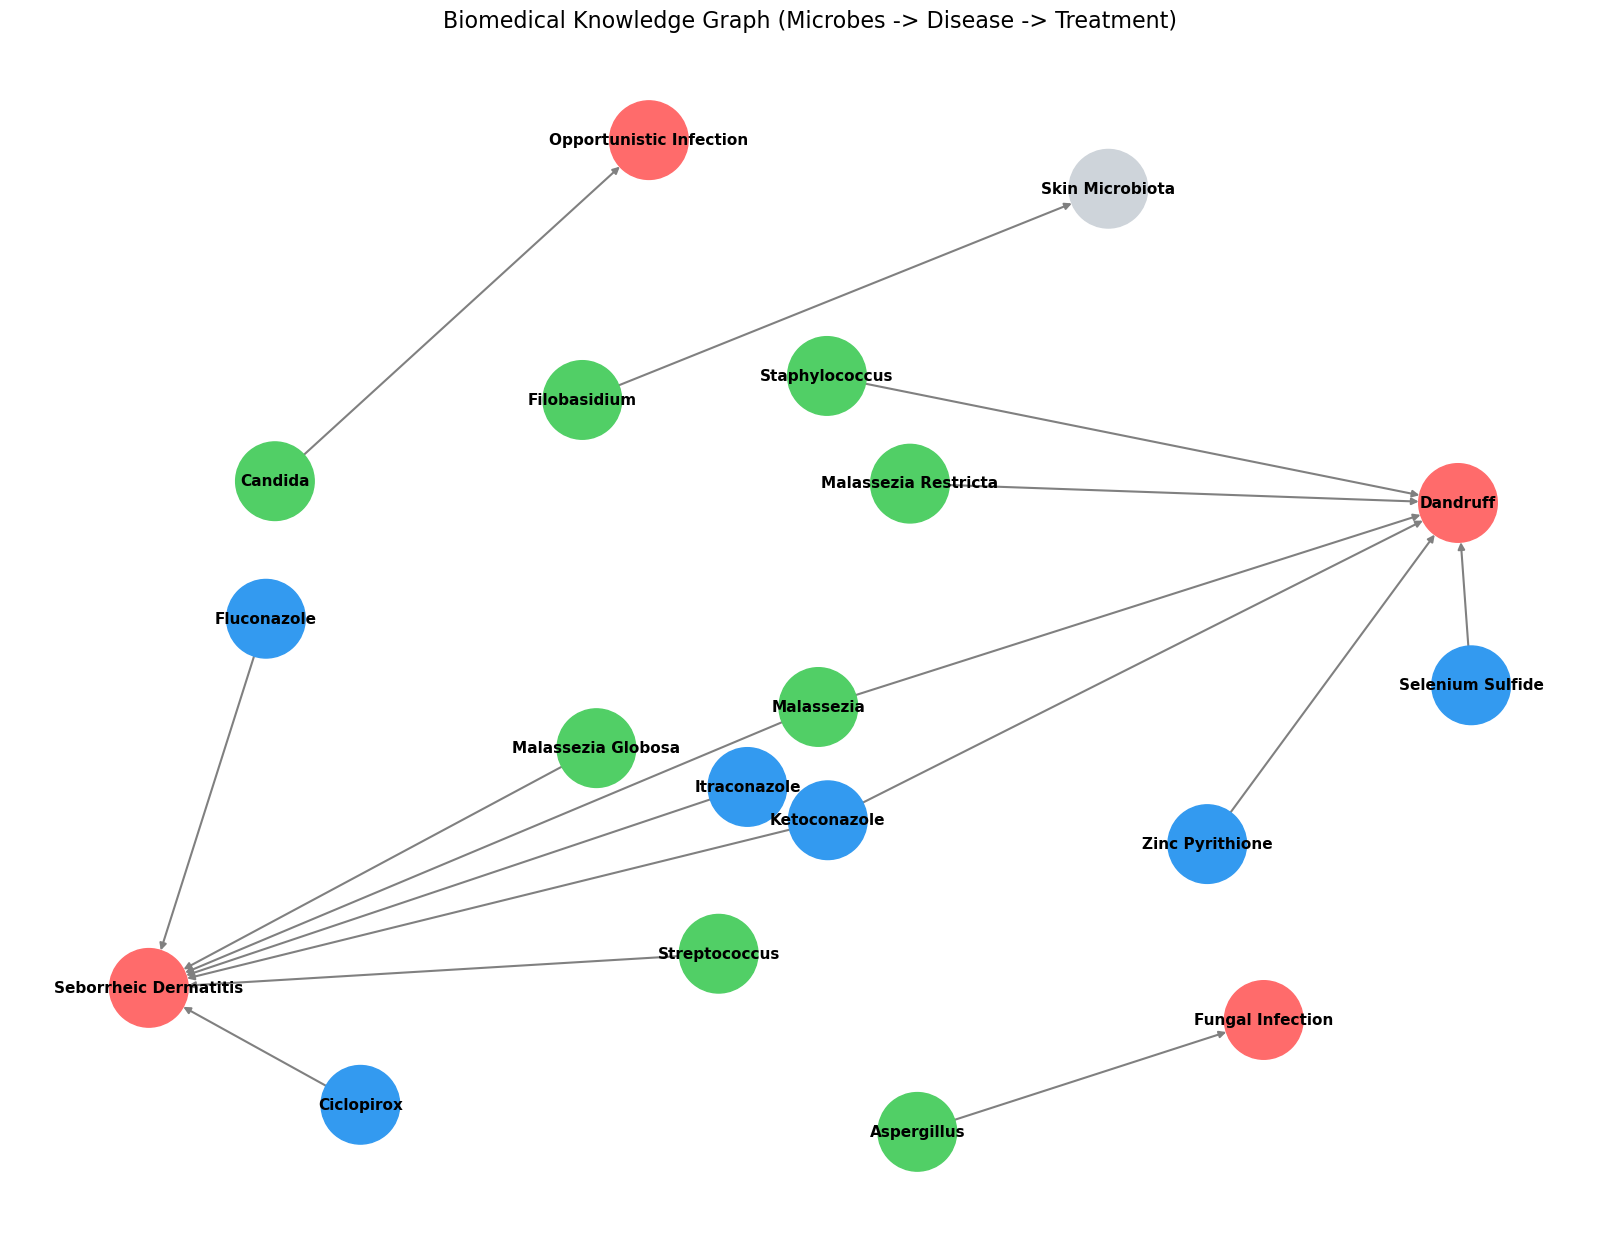

In [47]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(16, 12))

#Keep meaningful relations
important_relations = ["causes", "treats", "associated_with"]

G_best = nx.DiGraph()

for u, v, data in G.edges(data=True):
    if data.get("relation") in important_relations:
        
         
        if G.nodes[u].get('type') in ["Chemical", "Process"]:
            continue
        if G.nodes[v].get('type') in ["Chemical", "Process"]:
            continue

        G_best.add_edge(u, v, **data)
        G_best.nodes[u]['type'] = G.nodes[u].get('type')
        G_best.nodes[v]['type'] = G.nodes[v].get('type')

#Better spacing layout
pos = nx.spring_layout(G_best, k=2.8, iterations=200, seed=42)

 
color_map = []
for node, data in G_best.nodes(data=True):
    ntype = data.get('type', '')
    
    if ntype == "Disease":
        color_map.append("#ff6b6b")  # soft red
    elif ntype == "Microorganism":
        color_map.append("#51cf66")  # green
    elif ntype == "Drug":
        color_map.append("#339af0")  # blue
    else:
        color_map.append("#ced4da")  # gray

# here we Draw nodes
nx.draw(
    G_best,
    pos,
    node_color=color_map,
    with_labels=False,
    node_size=3200,
    edge_color="gray",
    arrows=True,
    width=1.5
)

#  Clean labels (bigger & bold)
nx.draw_networkx_labels(
    G_best,
    pos,
    font_size=11,
    font_weight='bold'
)

#  No edge labels 


plt.title("Biomedical Knowledge Graph (Microbes -> Disease -> Treatment)", fontsize=16)

plt.axis('off')
plt.show()

- Diseases (Dandruff, Seborrheic Dermatitis) act as central hubs
- Malassezia is the main microorganism linked to scalp diseases
- Multiple microbes (Staphylococcus, Streptococcus, Candida) contribute to disease
- One disease can have multiple treatments
- Dandruff → Zinc Pyrithione, Selenium Sulfide
- Seborrheic Dermatitis → Fluconazole, Ciclopirox
- Clear pathway: Microorganism → Disease → Drug
- Dandruff and Seborrheic Dermatitis are closely related diseases
- Graph also shows other infections (Candida → Opportunistic Infection, Aspergillus → Fungal Infection)
- Skin microbiota plays a role in maintaining scalp health

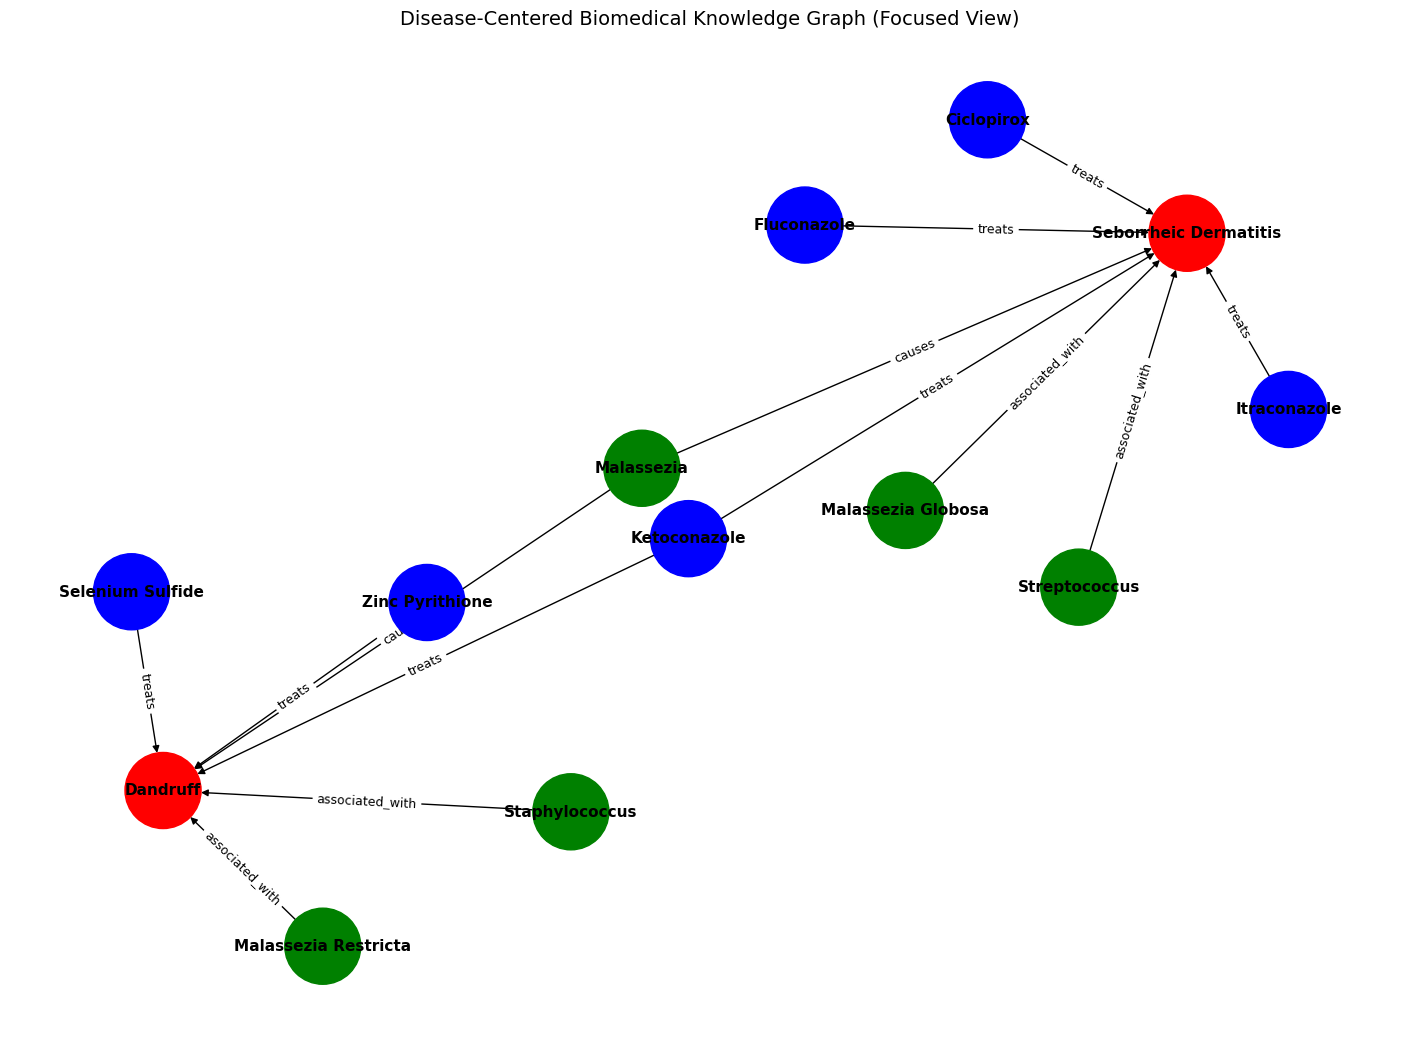

In [48]:
plt.figure(figsize=(14, 10))

# this spring_layout give for best  spacing
pos = nx.spring_layout(G_disease, k=1.2, iterations=100, seed=42)

#  Color mapping by node type
color_map = []
for node, data in G_disease.nodes(data=True):
    ntype = data.get('type', '')
    
    if ntype == "Disease":
        color_map.append("red")         
    elif ntype == "Microorganism":
        color_map.append("green")       
    elif ntype == "Drug":
        color_map.append("blue")       
    elif ntype == "Symptom":
        color_map.append("orange")      
    else:
        color_map.append("gray")         

# Draw nodes
nx.draw(
    G_disease,
    pos,
    node_color=color_map,
    node_size=3000,
    with_labels=False,
    arrows=True
)

# Draw labels (separate for clarity)
nx.draw_networkx_labels(
    G_disease,
    pos,
    font_size=11,
    font_weight='bold'
)

# Draw edge labels (relations)
edge_labels = nx.get_edge_attributes(G_disease, 'relation')
nx.draw_networkx_edge_labels(
    G_disease,
    pos,
    edge_labels=edge_labels,
    font_size=9,
    label_pos=0.5
)

plt.title("Disease-Centered Biomedical Knowledge Graph (Focused View)", fontsize=14)
plt.axis('off')
plt.show()

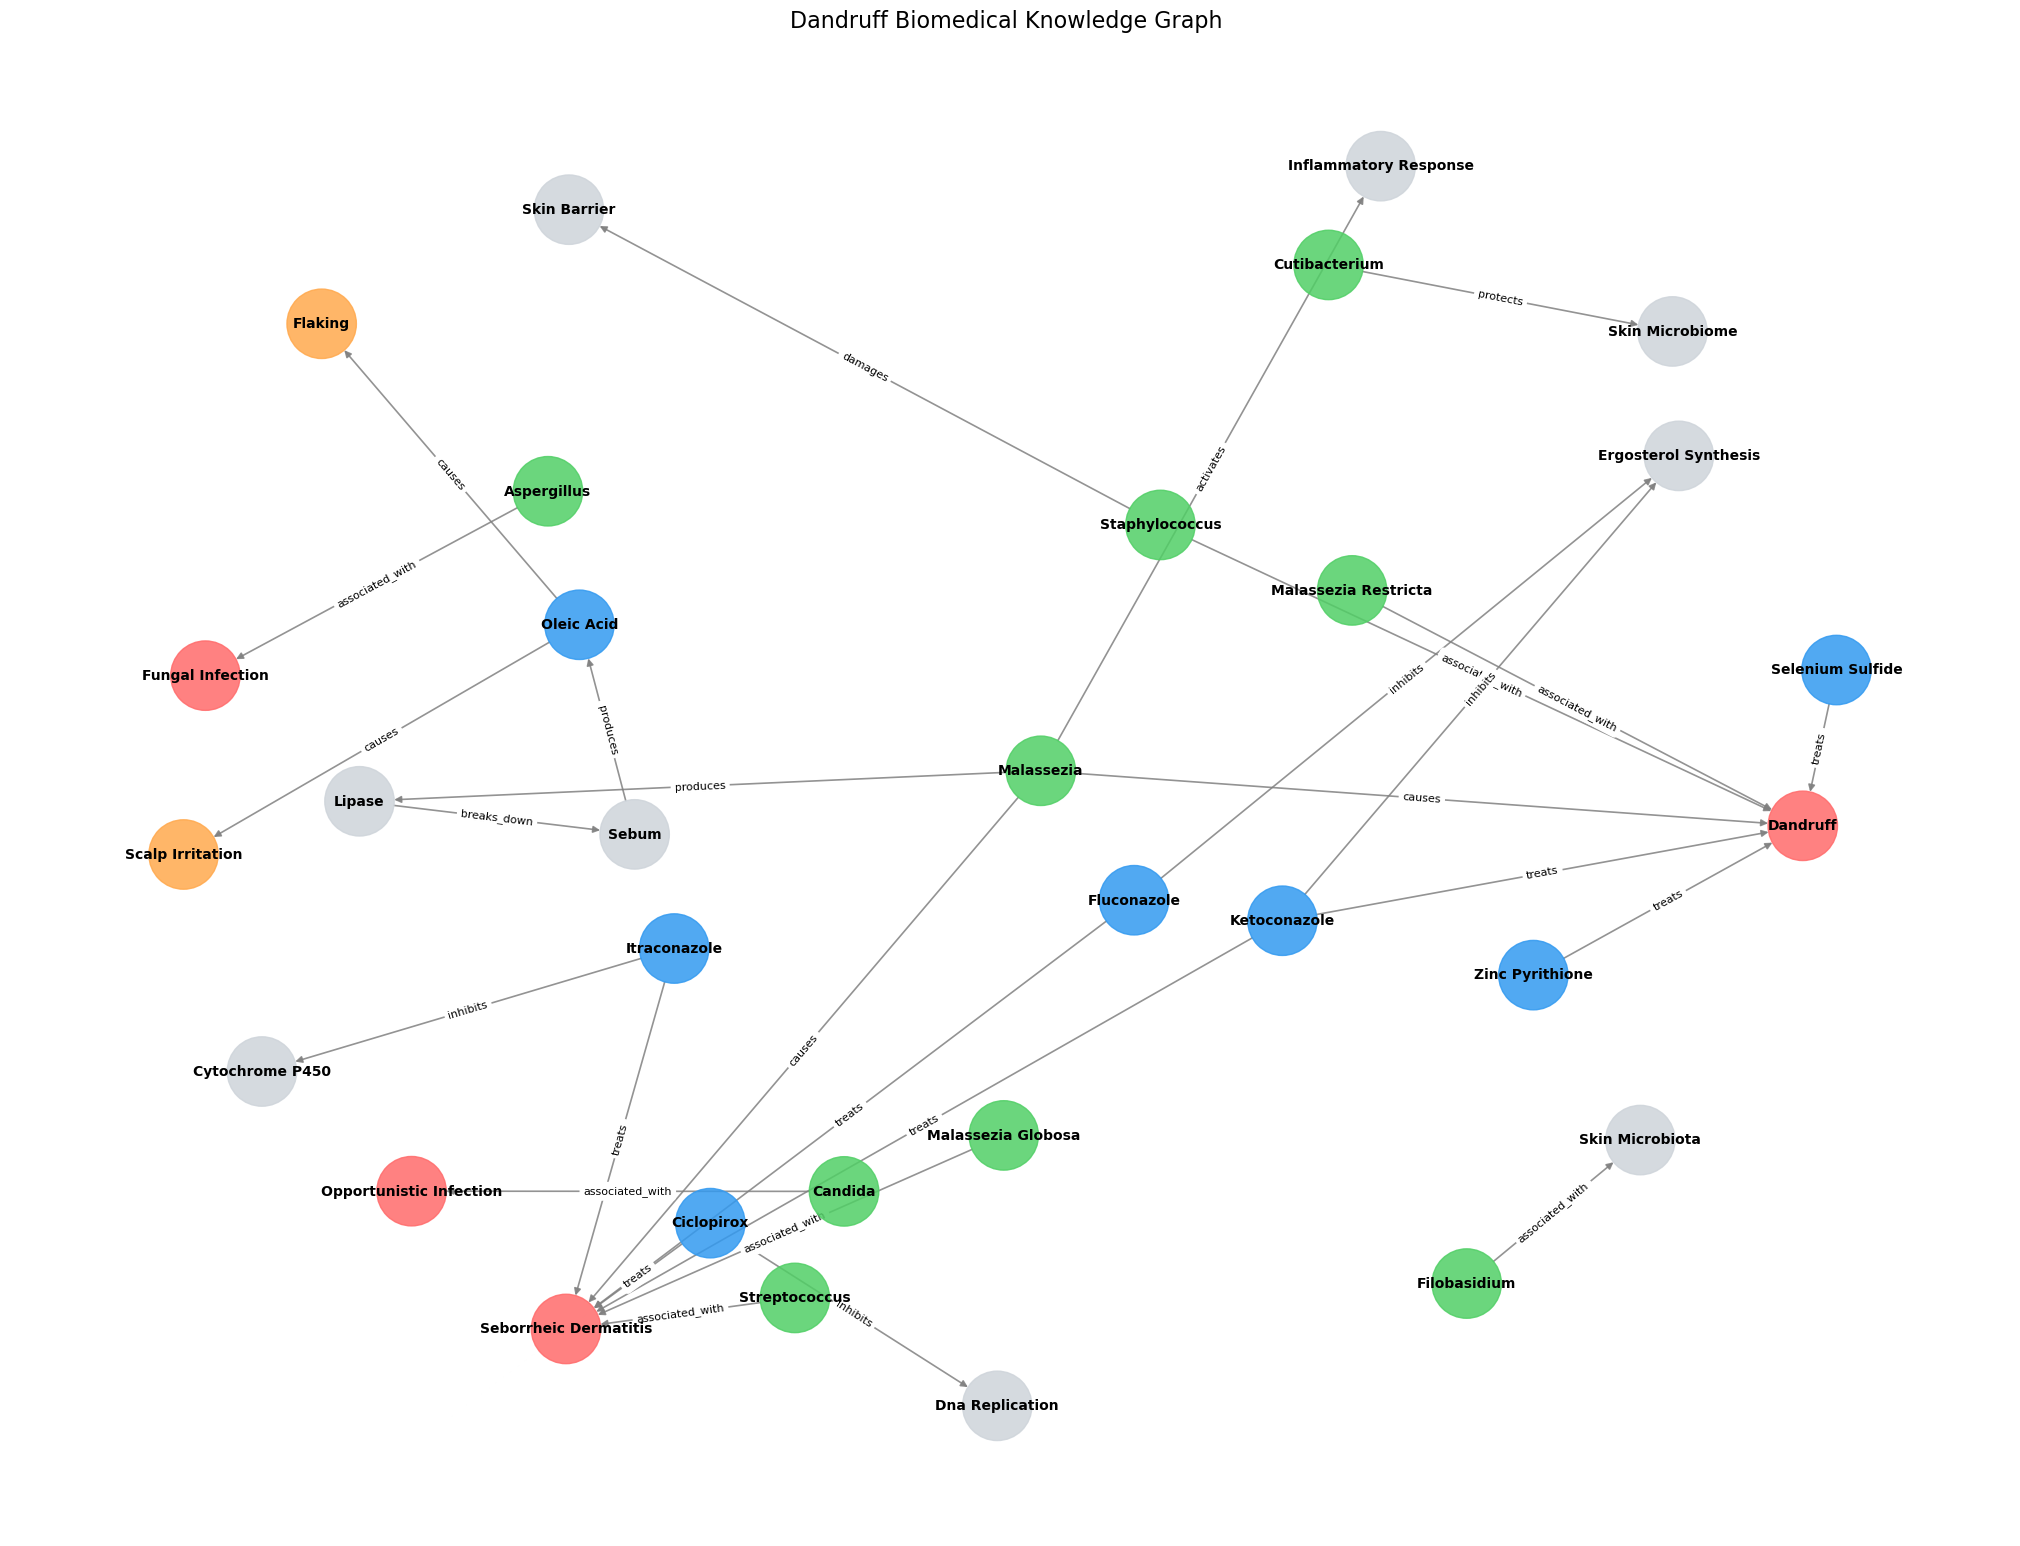

In [32]:
plt.figure(figsize=(20, 15))

# Create FULL graph (no filtering at all)
G_full = nx.DiGraph()

# Add ALL edges with ALL attributes
for u, v, data in G.edges(data=True):
    G_full.add_edge(u, v, **data)
    
    # preserve node attributes 
    if u in G.nodes:
        G_full.nodes[u].update(G.nodes[u])
    if v in G.nodes:
        G_full.nodes[v].update(G.nodes[v])

# Layout 
pos = nx.spring_layout(G_full, k=1.5, iterations=150, seed=42)

# Color mapping based on node type
color_map = []
for node, data in G_full.nodes(data=True):
    ntype = data.get('type', '').lower()

    if "disease" in ntype:
        color_map.append("#ff6b6b")   # red
    elif "micro" in ntype or "bacteria" in ntype or "fung" in ntype:
        color_map.append("#51cf66")   # green
    elif "drug" in ntype or "chemical" in ntype:
        color_map.append("#339af0")   # blue
    elif "symptom" in ntype:
        color_map.append("#ffa94d")   # orange
    else:
        color_map.append("#ced4da")   # gray


nx.draw(
    G_full,
    pos,
    node_color=color_map,
    with_labels=False,
    node_size=2500,
    edge_color="gray",
    arrows=True,
    width=1.2,
    alpha=0.85
)

# Labels
nx.draw_networkx_labels(
    G_full,
    pos,
    font_size=10,
    font_weight='bold'
)

# Edge labels (IMPORTANT: shows relationships)
edge_labels = nx.get_edge_attributes(G_full, 'relation')
nx.draw_networkx_edge_labels(
    G_full,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Dandruff Biomedical Knowledge Graph ", fontsize=16)
plt.axis('off')
plt.show()